In [1]:
import pandas as pd

df_model = pd.read_pickle('nhamcs_clean.pkl')
df_model['RACERETH'] = df_model['RACERETH'].astype('category')
df_model['IMMEDR'] = df_model['IMMEDR'].astype('category')
df_model['PAYTYPER'] = df_model['PAYTYPER'].astype('category')
print(df_model.dtypes)

WAITTIME               object
RACERETH             category
IMMEDR               category
AGE                     int16
SEX                      int8
ARREMS                 object
PAYTYPER             category
arrival_hour            Int64
NOT_SEEN_WAITTIME        bool
dtype: object


In [2]:
df_model['WAITTIME'] = df_model['WAITTIME'].astype('float')

In [3]:
import statsmodels.formula.api as smf

model = smf.ols('WAITTIME ~ C(RACERETH)', data=df_model).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               WAITTIME   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.474
Date:                Sun, 21 Jun 2026   Prob (F-statistic):             0.0153
Time:                        19:49:44   Log-Likelihood:                -45563.
No. Observations:                8247   AIC:                         9.113e+04
Df Residuals:                    8243   BIC:                         9.116e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           34.4044      0.892  

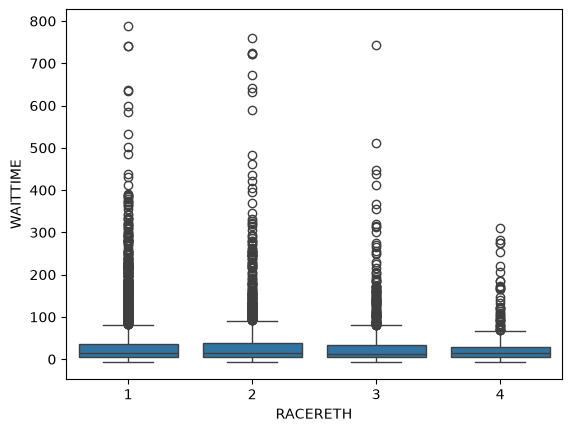

In [4]:
# boxplot: shows distribution by category
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x='RACERETH', y='WAITTIME', data=df_model)
plt.xticks()
plt.show()

In [15]:
# WAITTIME log transformation
import numpy as np
df_model['log_waittime'] = np.log(df_model['WAITTIME'] + 1) # add 1 to avoid log(0)

model_log = smf.ols('log_waittime ~ C(RACERETH)', data=df_model).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:           log_waittime   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.305
Date:                Sun, 21 Jun 2026   Prob (F-statistic):             0.0193
Time:                        20:03:18   Log-Likelihood:                -13723.
No. Observations:                7971   AIC:                         2.745e+04
Df Residuals:                    7967   BIC:                         2.748e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.7684      0.020  

/Users/amyyu/Desktop/Python_Projects/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
